### Upload Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install keras-utils

  Preparing metadata (setup.py) ... done
  Created wheel for keras-utils: filename=keras_utils-1.0.13-py3-none-any.whl size=2631 sha256=b310713cf5d8efddd551a57487400153cf7078b9a904c7c43156eb202ccabc2a
  Stored in directory: /root/.cache/pip/wheels/5c/c0/b3/0c332de4fd71f3733ea6d61697464b7ae4b2b5ff0300e6ca7a
Successfully built keras-utils


### Import Library

In [ ]:
from __future__ import print_function
import numpy as np
np.random.seed(1337)
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Lambda
from keras.layers import Embedding
from keras.layers import Conv1D,MaxPooling1D, Flatten
from keras.datasets import imdb
from keras import backend as K
import pandas as pd
from keras.utils import to_categorical

from sklearn.preprocessing import Normalizer
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, Flatten, MaxPooling1D
import numpy as np
import h5py
from keras import callbacks
from keras.layers import LSTM, GRU, SimpleRNN
from keras.callbacks import CSVLogger
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (precision_score, recall_score,f1_score, accuracy_score,mean_squared_error,mean_absolute_error)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import auc,roc_curve,roc_auc_score

### Upload Train and Test Dataset

In [ ]:
traindata = pd.read_csv('/content/drive/MyDrive/Cyber/M_Dataset_metasploitable-2_70.csv', header=None)
testdata = pd.read_csv('/content/drive/MyDrive/Cyber/M_Dataset_metasploitable-2_30.csv', header=None)

### Preprocessing Dataset

In [ ]:
from sklearn.preprocessing import LabelEncoder
for column in traindata.columns:
    if traindata[column].dtype == type(object):
        le = LabelEncoder()
        traindata[column] = le.fit_transform(traindata[column])


for column in testdata.columns:
    if testdata[column].dtype == type(object):
        le = LabelEncoder()
        testdata[column] = le.fit_transform(testdata[column])


X = traindata.iloc[:,0:83]
Y = traindata.iloc[:,83:84]


C = testdata.iloc[:,83:84]
T = testdata.iloc[:,0:83]

scaler = Normalizer().fit(X)
trainX = scaler.transform(X)

scaler = Normalizer().fit(T)
testT = scaler.transform(T)


traindata = np.array(trainX)
trainlabel = np.array(Y)

testdata = np.array(testT)
testlabel = np.array(C)
y_train1 = np.array(Y)

y_test1 = np.array(C)

y_train= to_categorical(y_train1)
y_test= to_categorical(y_test1)
X_train = np.reshape(trainX, (trainX.shape[0],trainX.shape[1],1))
X_test = np.reshape(testT, (testT.shape[0],testT.shape[1],1))


### Display train Dataset

In [ ]:
import pandas as pd
# dataset DataFrame
traindata = pd.read_csv('/content/drive/MyDrive/Cyber/M_Dataset_metasploitable-2_70.csv', header=None)
# Display
traindata.head()


,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
0,192.168.3.130-200.175.2.130-38693-4444-6,192.168.3.130,38693,200.175.2.130,4444,6,10/1/2020 5:02,268599,2,3,...,0,0.0,0.0,0,0,0.0,0.0,0,0,U2R
1,192.168.3.130-200.175.2.130-3632-33747-6,200.175.2.130,33747,192.168.3.130,3632,6,10/1/2020 5:02,22194,5,5,...,0,0.0,0.0,0,0,0.0,0.0,0,0,U2R
2,192.168.3.130-200.175.2.130-8180-37217-6,200.175.2.130,37217,192.168.3.130,8180,6,10/1/2020 1:39,8782,4,4,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA
3,192.168.3.130-200.175.2.130-8180-35921-6,200.175.2.130,35921,192.168.3.130,8180,6,10/1/2020 1:39,4047,2,2,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA
4,192.168.3.130-200.175.2.130-8180-43053-6,200.175.2.130,43053,192.168.3.130,8180,6,10/1/2020 1:39,3819,2,2,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA


### Display Test Dataset

In [ ]:
# test dataset DataFrame
testdata = pd.read_csv('/content/drive/MyDrive/Cyber/M_Dataset_metasploitable-2_30.csv', header=None)
# Display
testdata.head()

,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
0,192.168.3.130-200.175.2.130-8180-38745-6,200.175.2.130,38745,192.168.3.130,8180,6,10/1/2020 1:39,9556,4,4,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA
1,192.168.3.130-200.175.2.130-8180-34573-6,200.175.2.130,34573,192.168.3.130,8180,6,10/1/2020 1:39,9383,4,4,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA
2,192.168.3.130-200.175.2.130-8180-40447-6,200.175.2.130,40447,192.168.3.130,8180,6,10/1/2020 1:39,9436,4,4,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA
3,192.168.3.130-200.175.2.130-8180-36099-6,200.175.2.130,36099,192.168.3.130,8180,6,10/1/2020 1:39,9020,4,4,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA
4,192.168.3.130-200.175.2.130-8180-39599-6,200.175.2.130,39599,192.168.3.130,8180,6,10/1/2020 1:39,2950,2,2,...,0,0.0,0.0,0,0,0.0,0.0,0,0,BFA


### Feature Extraction and Selection using PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# 1. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 2. Dimensionality Reduction (PCA)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(X_pca)

[[-1.48805435  0.21244703  0.13088841 ...  0.2380079   0.54871696
   0.65675416]
 [-1.57106659  0.27048229  0.21820178 ...  0.22850603  0.51964616
   0.7129511 ]
 [-1.5484244   0.20078439  0.2426085  ...  0.18644701  0.53354049
   0.57984554]
 ...
 [-1.2432837   0.64718079 -0.62072525 ...  0.24846831 -0.51598953
   0.31308232]
 [-1.48176531  0.62421269 -0.46563274 ...  0.18539555 -0.18988032
   0.30370625]
 [-1.15637811  0.96513341 -0.87299305 ...  0.30134333 -0.57440772
   0.33250632]]


In [ ]:
# Assuming pca is the trained PCA model
components = pca.components_

for i in range(10):
    print("Component", i+1)
    print("Top 5 features contributing to this component (by index):")
    sorted_indices = components[i].argsort()[::-1][:5]
    print(sorted_indices)
    print("\n")


Component 1
Top 5 features contributing to this component (by index):
[31  7 24 81 34]


Component 2
Top 5 features contributing to this component (by index):
[46 45 58 47 16]


Component 3
Top 5 features contributing to this component (by index):
[41  9 69 40  8]


Component 4
Top 5 features contributing to this component (by index):
[ 4 49 14 59 15]


Component 5
Top 5 features contributing to this component (by index):
[15 14 59 12 43]


Component 6
Top 5 features contributing to this component (by index):
[44  5 17 57 13]


Component 7
Top 5 features contributing to this component (by index):
[75 77 73 78 76]


Component 8
Top 5 features contributing to this component (by index):
[68 10 73 21 43]


Component 9
Top 5 features contributing to this component (by index):
[68 10 53 72 73]


Component 10
Top 5 features contributing to this component (by index):
[78 82 79 22 15]




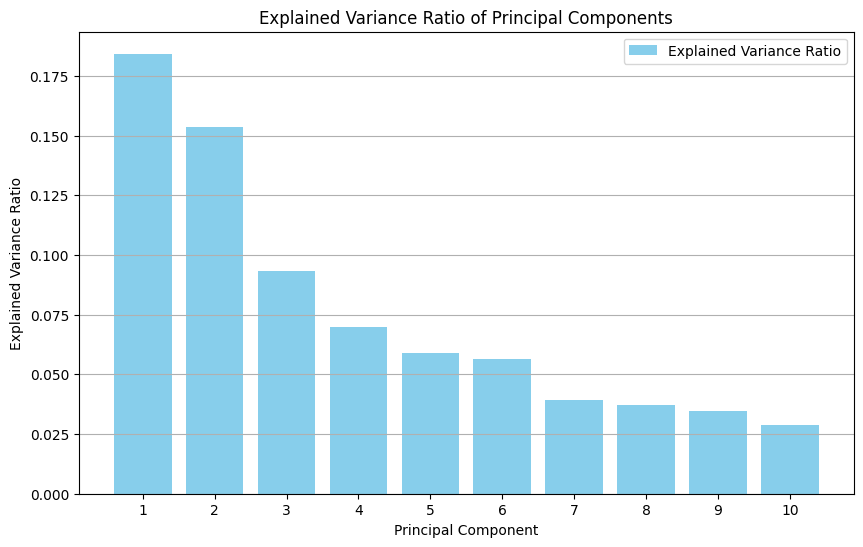

In [ ]:
import matplotlib.pyplot as plt

# Assuming pca is your PCA model
explained_variance_ratio = pca.explained_variance_ratio_

# Create a bar plot to show the explained variance ratio of each principal component
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, label='Explained Variance Ratio', color='skyblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.legend()
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(axis='y')
plt.show()


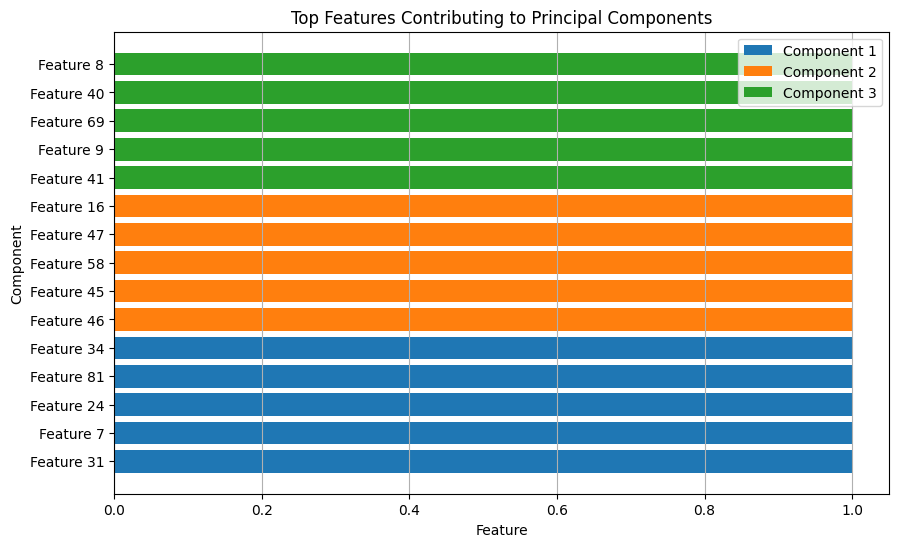

In [ ]:
# Define the features for each component
components_features = {
    "Component 1": ["Feature 31", "Feature 7", "Feature 24", "Feature 81", "Feature 34"],
    "Component 2": ["Feature 46", "Feature 45", "Feature 58", "Feature 47", "Feature 16"],
    "Component 3": ["Feature 41", "Feature 9", "Feature 69", "Feature 40", "Feature 8"],
    # Add other components similarly...
}

# Plot the horizontal bar plot for each component
plt.figure(figsize=(10, 6))
for component, features in components_features.items():
    plt.barh(features, [1]*len(features), label=component)

plt.xlabel('Feature')
plt.ylabel('Component')
plt.title('Top Features Contributing to Principal Components')
plt.legend()
plt.grid(axis='x')
plt.show()


### Correlation Heatmap

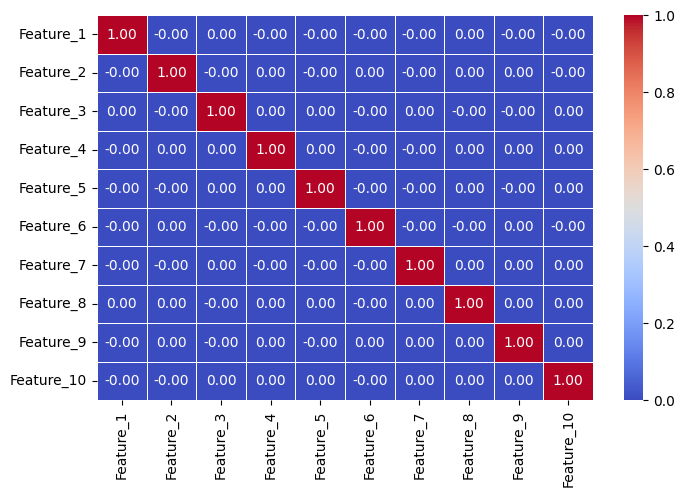

In [ ]:
import seaborn as sns

# Assuming X_pca is your extracted feature matrix and df is your DataFrame
df_pca = pd.DataFrame(X_pca, columns=[f'Feature_{i+1}' for i in range(X_pca.shape[1])])
correlation_matrix = df_pca.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.show()


### Feature Importance

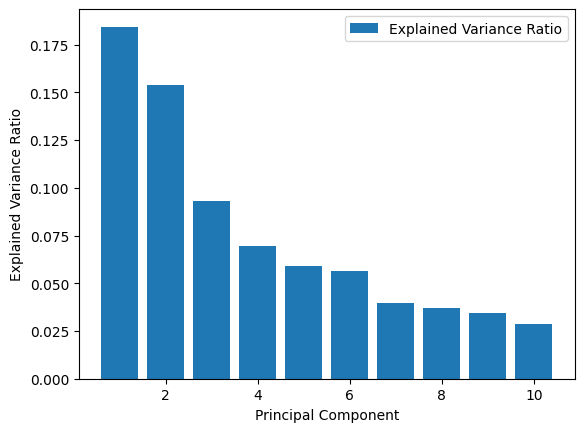

In [ ]:
# Assuming pca is your PCA model
explained_variance_ratio = pca.explained_variance_ratio_

plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, label='Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.show()


### Making Function for Recall, Precision, Accuracy and F1-Score

In [ ]:
# multi-class precision,recall, and accuracy
def accuracy(confusion_matrix):
    diagonal_sum = confusion_matrix.trace()
    sum_of_all_elements = confusion_matrix.sum()
    return diagonal_sum / sum_of_all_elements

def precision(label, confusion_matrix):
    col = confusion_matrix[:, label]
    return confusion_matrix[label, label] / col.sum()

def recall(label, confusion_matrix):
    row = confusion_matrix[label, :]
    return confusion_matrix[label, label] / row.sum()

def precision_macro_average(confusion_matrix):
    rows, columns = confusion_matrix.shape
    sum_of_precisions = 0
    for label in range(rows):
        sum_of_precisions += precision(label, confusion_matrix)
    return sum_of_precisions / rows

def recall_macro_average(confusion_matrix):
    rows, columns = confusion_matrix.shape
    sum_of_recalls = 0
    for label in range(columns):
        sum_of_recalls += recall(label, confusion_matrix)
    return sum_of_recalls / columns
# multi-class precision,recall, and accuracy
def accuracy(confusion_matrix):
    diagonal_sum = confusion_matrix.trace()
    sum_of_all_elements = confusion_matrix.sum()
    return diagonal_sum / sum_of_all_elements

def precision(label, confusion_matrix):
    col = confusion_matrix[:, label]
    return confusion_matrix[label, label] / col.sum()

def recall(label, confusion_matrix):
    row = confusion_matrix[label, :]
    return confusion_matrix[label, label] / row.sum()

def precision_macro_average(confusion_matrix):
    rows, columns = confusion_matrix.shape
    sum_of_precisions = 0
    for label in range(rows):
        sum_of_precisions += precision(label, confusion_matrix)
    return sum_of_precisions / rows

def recall_macro_average(confusion_matrix):
    rows, columns = confusion_matrix.shape
    sum_of_recalls = 0
    for label in range(columns):
        sum_of_recalls += recall(label, confusion_matrix)
    return sum_of_recalls / columns

**SVM**

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9528185478633588
Precision: 0.9475559961247411
Recall: 0.9528185478633588
F1 Score: 0.9487261553983819
Confusion Matrix:
[[    0     0     0     2    92     0]
 [    0 21798     0    16   127     0]
 [    0     0     0   320    26     0]
 [    0     3     0 20515    44     0]
 [    0   950     0  1321 16373     0]
 [    0     0     0     5     0     0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


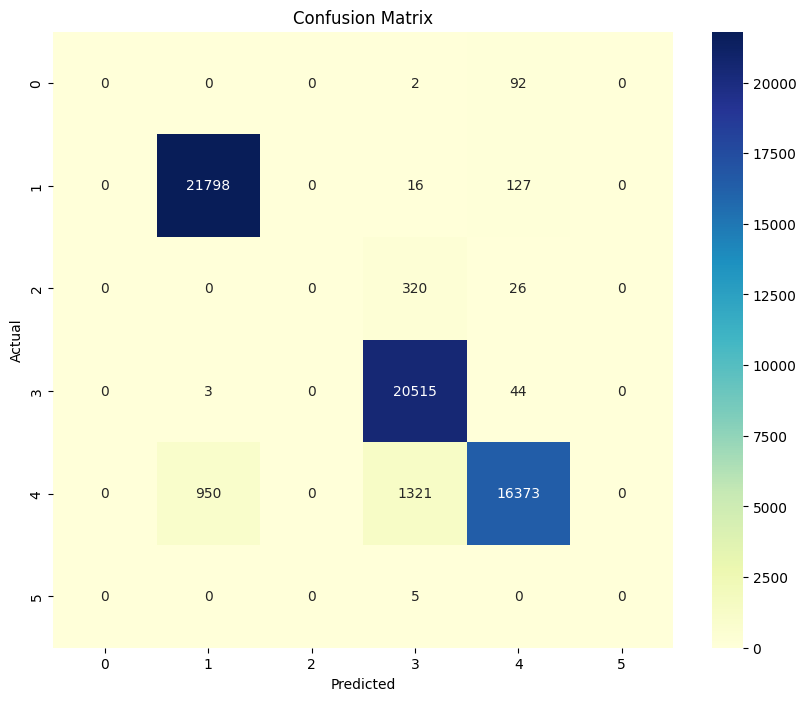

In [ ]:
from sklearn.svm import SVC

# Create SVM model
svm_model = SVC(kernel='rbf', gamma='auto', C=1.0)  # You can adjust hyperparameters like kernel, gamma, and C
# Reshape the input data to 2 dimensions
X_train = np.reshape(trainX, (trainX.shape[0], trainX.shape[1]))
X_test = np.reshape(testT, (testT.shape[0], testT.shape[1]))

# Create SVM model
svm_model = SVC(kernel='rbf', gamma='auto', C=1.0)  # You can adjust hyperparameters like kernel, gamma, and C

# Train the model
svm_model.fit(X_train, y_train1)

# Predictions on test data
y_pred = svm_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test1, y_pred))
print("Precision:", precision_score(y_test1, y_pred, average='weighted'))
print("Recall:", recall_score(y_test1, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test1, y_pred, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(y_test1, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sn.heatmap(cm, annot=True, cmap="YlGnBu", fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**RANDOM FOREST**

<ipython-input-32-86697c5dc87a>:11: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_model.fit(X_train, y_train1)


Accuracy: 0.9500097415248734
Precision: 0.9563256392488784
Recall: 0.9500097415248734
F1 Score: 0.9494776011891634
Confusion Matrix:
[[   59     0     0    34     0     1]
 [    0 21941     0     0     0     0]
 [    0     0   328     5    13     0]
 [    0     0     0 20562     0     0]
 [    0     0    27  2997 15620     0]
 [    0     0     0     2     0     3]]


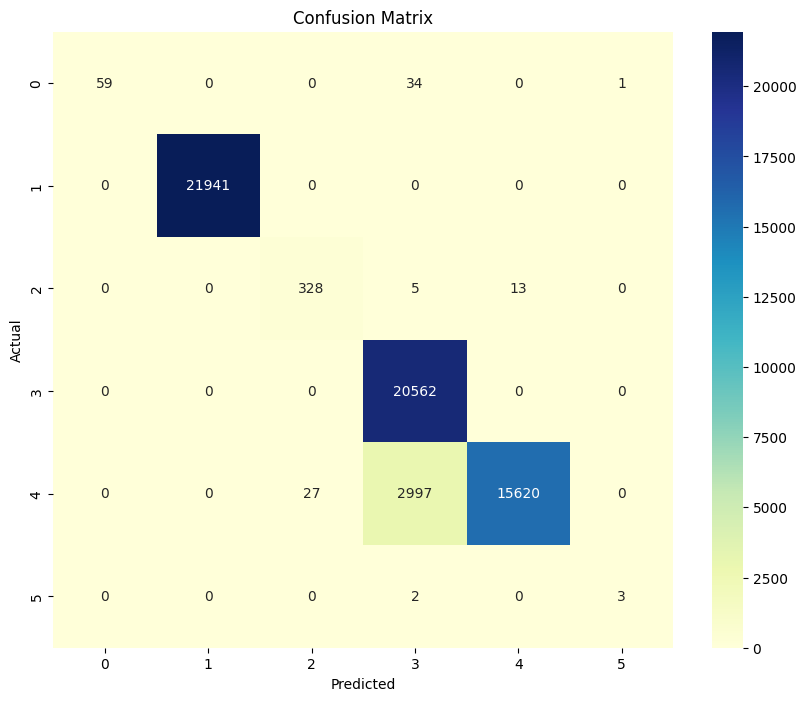

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Assuming X_train and X_test have shape (num_samples, num_features, num_time_steps)
# Reshape the input data to have 2 dimensions
X_train = X_train.reshape(X_train.shape[0], -1)  # Reshape to (num_samples, num_features * num_time_steps)
X_test = X_test.reshape(X_test.shape[0], -1)     # Reshape to (num_samples, num_features * num_time_steps)

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust the number of estimators and other hyperparameters

# Train the model
rf_model.fit(X_train, y_train1)

# Predictions on test data
y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test1, y_pred))
print("Precision:", precision_score(y_test1, y_pred, average='weighted'))
print("Recall:", recall_score(y_test1, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test1, y_pred, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(y_test1, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sn.heatmap(cm, annot=True, cmap="YlGnBu", fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train1)

# Predictions on test data
y_pred = dt_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.8998246525522795
Precision: 0.9223915548840586
Recall: 0.8998246525522795
F1 Score: 0.8963789909409204


Confusion Matrix:
[[   13     0    15    65     0     1]
 [    0 21940     0     1     0     0]
 [    0     1   261    78     6     0]
 [    0     1     0 20552     9     0]
 [    0     0    12  5978 12654     0]
 [    0     0     0     2     1     2]]


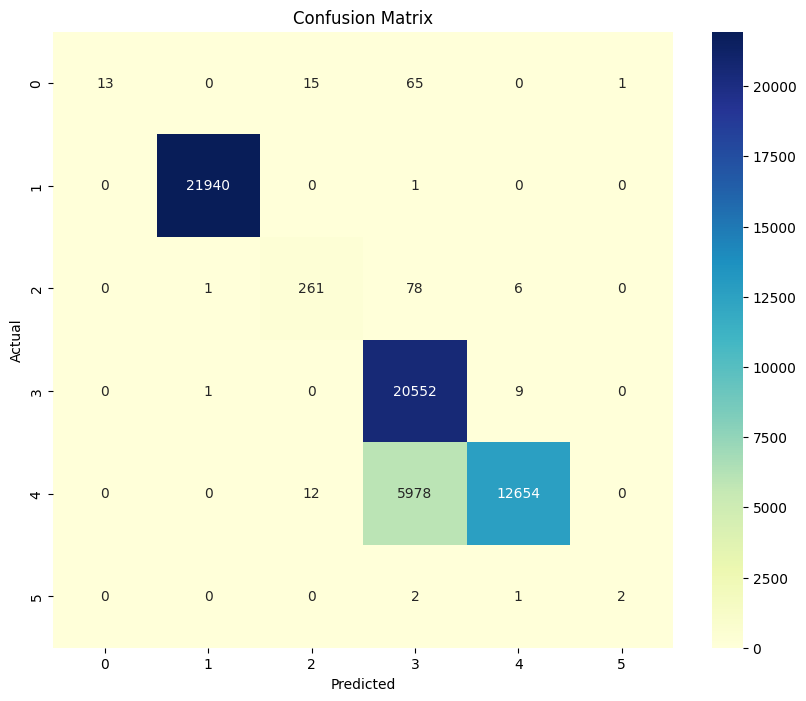

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test1, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="YlGnBu", fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create KNN model
# Create KNN model with a smaller number of neighbors
knn_model = KNeighborsClassifier(n_neighbors=1)  # Adjust the number of neighbors here
 # You can adjust the number of neighbors (k)

# Train the model
knn_model.fit(X_train, y_train1)

# Predictions on test data
y_pred = knn_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy: 0.9666677490583193
Precision: 0.9704312272903463
Recall: 0.9666677490583193
F1 Score: 0.9668312414970112


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.utils import shuffle

# Shuffle the training data to introduce randomness
X_train_shuffled, y_train_shuffled = shuffle(X_train, y_train1)

# Create KNN model with a smaller number of neighbors
knn_model = KNeighborsClassifier(n_neighbors=1)  # Adjust the number of neighbors here

# Train the model on shuffled data
knn_model.fit(X_train_shuffled, y_train_shuffled)


# Predictions on test data
y_pred = knn_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy: 0.9666677490583193
Precision: 0.9704312272903463
Recall: 0.9666677490583193
F1 Score: 0.9668312414970112


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test1, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="YlGnBu", fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print("Accuracy KNN:", accuracy * 100)


Accuracy KNN: 97.45583842057411


**Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train1)

# Predictions on test data
y_pred = nb_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9334004416157943
Precision: 0.9845483345934547
Recall: 0.9334004416157943
F1 Score: 0.9555983757917351


In [ ]:
print("Accuracy Naive:", accuracy * 100)

Accuracy: 93.34004416157943


In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
conf_matrix = confusion_matrix(y_test1, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[   13     0    15    65     0     1]
 [    0 21940     0     1     0     0]
 [    0     1   261    78     6     0]
 [    0     1     0 20552     9     0]
 [    0     0    12  5978 12654     0]
 [    0     0     0     2     1     2]]


In [ ]:
print(data.columns)


Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

In [ ]:
num_features = len(data.columns)
print("Total number of features:", num_features)


Total number of features: 84


Code to make dictionory of the features and extracted the names of it


In [ ]:
# Define a dictionary to map feature numbers to feature names
feature_names = {
    1: "Flow ID", 2: "Src IP", 3: "Src Port", 4: "Dst IP", 5: "Dst Port", 6: "Protocol",
    7: "Timestamp", 8: "Flow Duration", 9: "Tot Fwd Pkts", 10: "Tot Bwd Pkts",
    11: "TotLen Fwd Pkts", 12: "TotLen Bwd Pkts", 13: "Fwd Pkt Len Max", 14: "Fwd Pkt Len Min",
    15: "Fwd Pkt Len Mean", 16: "Fwd Pkt Len Std", 17: "Bwd Pkt Len Max", 18: "Bwd Pkt Len Min",
    19: "Bwd Pkt Len Mean", 20: "Bwd Pkt Len Std", 21: "Flow Byts/s", 22: "Flow Pkts/s",
    23: "Flow IAT Mean", 24: "Flow IAT Std", 25: "Flow IAT Max", 26: "Flow IAT Min",
    27: "Fwd IAT Tot", 28: "Fwd IAT Mean", 29: "Fwd IAT Std", 30: "Fwd IAT Max",
    31: "Fwd IAT Min", 32: "Bwd IAT Tot", 33: "Bwd IAT Mean", 34: "Bwd IAT Std",
    35: "Bwd IAT Max", 36: "Bwd IAT Min", 37: "Fwd PSH Flags", 38: "Bwd PSH Flags",
    39: "Fwd URG Flags", 40: "Bwd URG Flags", 41: "Fwd Header Len", 42: "Bwd Header Len",
    43: "Fwd Pkts/s", 44: "Bwd Pkts/s", 45: "Pkt Len Min", 46: "Pkt Len Max",
    47: "Pkt Len Mean", 48: "Pkt Len Std", 49: "Pkt Len Var", 50: "FIN Flag Cnt",
    51: "SYN Flag Cnt", 52: "RST Flag Cnt", 53: "PSH Flag Cnt", 54: "ACK Flag Cnt",
    55: "URG Flag Cnt", 56: "CWE Flag Count", 57: "ECE Flag Cnt", 58: "Down/Up Ratio",
    59: "Pkt Size Avg", 60: "Fwd Seg Size Avg", 61: "Bwd Seg Size Avg", 62: "Fwd Byts/b Avg",
    63: "Fwd Pkts/b Avg", 64: "Fwd Blk Rate Avg", 65: "Bwd Byts/b Avg", 66: "Bwd Pkts/b Avg",
    67: "Bwd Blk Rate Avg", 68: "Subflow Fwd Pkts", 69: "Subflow Fwd Byts",
    70: "Subflow Bwd Pkts", 71: "Subflow Bwd Byts", 72: "Init Fwd Win Byts",
    73: "Init Bwd Win Byts", 74: "Fwd Act Data Pkts", 75: "Fwd Seg Size Min",
    76: "Active Mean", 77: "Active Std", 78: "Active Max", 79: "Active Min",
    80: "Idle Mean", 81: "Idle Std", 82: "Idle Max", 83: "Idle Min", 84: "Label"
}

# Iterate over the components dictionary and replace feature numbers with feature names
components_features_names = {}
for component, features in components_features.items():
    component_features_names = [feature_names[int(feature.split()[-1])] for feature in features]
    components_features_names[component] = component_features_names

# Print the updated components dictionary with feature names
for component, features in components_features_names.items():
    print(f"{component}: {features}")


Component 1: ['Fwd IAT Min', 'Timestamp', 'Flow IAT Std', 'Idle Std', 'Bwd IAT Std']
Component 2: ['Pkt Len Max', 'Pkt Len Min', 'Down/Up Ratio', 'Pkt Len Mean', 'Fwd Pkt Len Std']
Component 3: ['Fwd Header Len', 'Tot Fwd Pkts', 'Subflow Fwd Byts', 'Bwd URG Flags', 'Flow Duration']
Component 4: ['Dst IP', 'Pkt Len Var', 'Fwd Pkt Len Min', 'Pkt Size Avg', 'Fwd Pkt Len Mean']
Component 5: ['Fwd Pkt Len Mean', 'Fwd Pkt Len Min', 'Pkt Size Avg', 'TotLen Bwd Pkts', 'Fwd Pkts/s']
Component 6: ['Bwd Pkts/s', 'Dst Port', 'Bwd Pkt Len Max', 'ECE Flag Cnt', 'Fwd Pkt Len Max']
Component 7: ['Fwd Seg Size Min', 'Active Std', 'Init Bwd Win Byts', 'Active Max', 'Active Mean']
Component 8: ['Subflow Fwd Pkts', 'Tot Bwd Pkts', 'Init Bwd Win Byts', 'Flow Byts/s', 'Fwd Pkts/s']
Component 9: ['Subflow Fwd Pkts', 'Tot Bwd Pkts', 'PSH Flag Cnt', 'Init Fwd Win Byts', 'Init Bwd Win Byts']
Component 10: ['Active Max', 'Idle Max', 'Active Min', 'Flow Pkts/s', 'Fwd Pkt Len Mean']


**Most important features across the components**

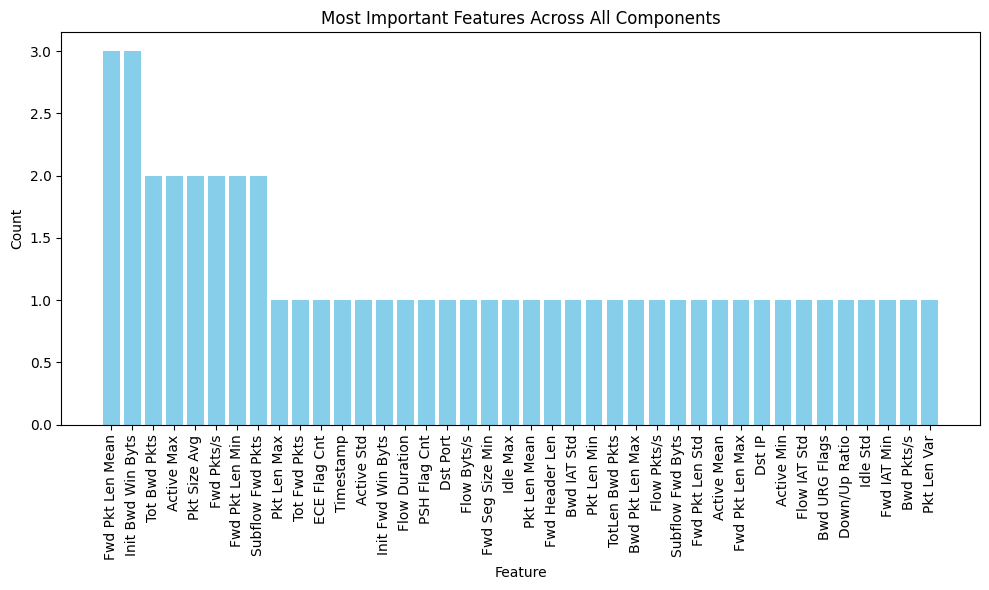

In [ ]:
import matplotlib.pyplot as plt

# Flatten the list of features across all components
all_features = [feature for features in components_features_names.values() for feature in features]

# Count the occurrences of each feature
feature_counts = {feature: all_features.count(feature) for feature in set(all_features)}

# Sort the features by their counts in descending order
sorted_features = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)

# Extract the feature names and their counts
features, counts = zip(*sorted_features)

# Plot the most important features
plt.figure(figsize=(10, 6))
plt.bar(features, counts, color='skyblue')
plt.xlabel('Feature')
plt.ylabel('Count')
plt.title('Most Important Features Across All Components')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**CPU UTILIZATION CHECK**

In [ ]:
!pip install psutil


In [ ]:
import psutil

# Function to get CPU utilization
def get_cpu_utilization():
    return psutil.cpu_percent(interval=1)

# Example usage:
print("CPU Utilization:", get_cpu_utilization(), "%")


CPU Utilization: 69.5 %


**Utilization from 1 to 38**

In [ ]:
import psutil

# Function to get CPU utilization
def get_cpu_utilization():
    return psutil.cpu_percent(interval=1)

# Loop through each cell
for i in range(1, 38):  # Assuming you have 37 cells
    print("Starting Cell", i)
    print("CPU Utilization:", get_cpu_utilization(), "%")
    # Your code for each model in each cell goes here
    print("Finished Cell", i)
    print("CPU Utilization:", get_cpu_utilization(), "%")


Starting Cell 1
CPU Utilization: 50.0 %
Finished Cell 1
CPU Utilization: 67.8 %
Starting Cell 2
CPU Utilization: 99.5 %
Finished Cell 2
CPU Utilization: 99.5 %
Starting Cell 3
CPU Utilization: 99.5 %
Finished Cell 3
CPU Utilization: 21.5 %
Starting Cell 4
CPU Utilization: 2.5 %
Finished Cell 4
CPU Utilization: 2.5 %
Starting Cell 5
CPU Utilization: 2.0 %
Finished Cell 5
CPU Utilization: 3.0 %
Starting Cell 6
CPU Utilization: 3.0 %
Finished Cell 6
CPU Utilization: 3.0 %
Starting Cell 7
CPU Utilization: 4.0 %
Finished Cell 7
CPU Utilization: 2.5 %
Starting Cell 8
CPU Utilization: 3.0 %
Finished Cell 8
CPU Utilization: 43.0 %
Starting Cell 9
CPU Utilization: 58.1 %
Finished Cell 9
CPU Utilization: 23.5 %
Starting Cell 10
CPU Utilization: 2.5 %
Finished Cell 10
CPU Utilization: 2.0 %
Starting Cell 11
CPU Utilization: 3.0 %
Finished Cell 11
CPU Utilization: 2.5 %
Starting Cell 12
CPU Utilization: 4.0 %
Finished Cell 12
CPU Utilization: 2.5 %
Starting Cell 13
CPU Utilization: 3.0 %
Finished 

**Utilization time for the SVM**

In [ ]:
def get_cpu_utilization():
    return psutil.cpu_percent(interval=1)
i=39
print("Starting Cell", i)
print("CPU Utilization:", get_cpu_utilization(), "%")
print("Finished Cell", i)
print("CPU Utilization:", get_cpu_utilization(), "%")


Starting Cell 39
CPU Utilization: 90.0 %
Finished Cell 39
CPU Utilization: 55.0 %
